In [2]:
import os
import json
import time
import random

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
from PIL import Image, UnidentifiedImageError
from IPython.display import display

In [5]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

In [6]:

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support
from sklearn.utils.class_weight import compute_class_weight

In [7]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [7]:
print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [8]:
try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    drive.mount("/content/drive")

Mounted at /content/drive


In [9]:
SCRIPT_DIR = os.getcwd()

IMG_HEIGHT = 128
IMG_WIDTH = 128
IMAGE_SIZE = (IMG_HEIGHT, IMG_WIDTH)
INPUT_SHAPE = (IMG_HEIGHT, IMG_WIDTH, 3)
BATCH_SIZE = 32

BASELINE_EPOCHS = 20
DEEP_EPOCHS = 25
TRANSFER_HEAD_EPOCHS = 8
TRANSFER_FINE_TUNE_EPOCHS = 8

VALID_EXT = (".png", ".jpg", ".jpeg", ".bmp", ".ppm")

In [10]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [11]:
def resolve_dataset_paths():
    candidate_roots = [
        "/content/drive/MyDrive/Traffic_Sign (1)",
        os.path.join(SCRIPT_DIR, "Traffic_Sign", "Traffic_Sign"),
        os.path.join(SCRIPT_DIR, "Traffic_Sign"),
    ]

    for root in candidate_roots:
        train_dir = os.path.join(root, "Train")
        test_dir = os.path.join(root, "Test")
        if os.path.isdir(train_dir) and os.path.isdir(test_dir):
            return root, train_dir, test_dir

        train_dir = os.path.join(root, "train")
        test_dir = os.path.join(root, "test")
        if os.path.isdir(train_dir) and os.path.isdir(test_dir):
            return root, train_dir, test_dir

    raise FileNotFoundError(
        f"Could not find dataset root. Checked: {candidate_roots}"
    )

In [12]:
DATASET_ROOT, TRAIN_DIR, TEST_DIR = resolve_dataset_paths()

OUTPUT_DIR = (
    "/content/traffic_sign_outputs"
    if IN_COLAB
    else os.path.join(SCRIPT_DIR, "traffic_sign_outputs}")
)

os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Dataset root:", DATASET_ROOT)
print("Train dir:", TRAIN_DIR)
print("Test dir:", TEST_DIR)
print("Output dir:", OUTPUT_DIR)

Dataset root: /content/drive/MyDrive/Traffic_Sign (1)
Train dir: /content/drive/MyDrive/Traffic_Sign (1)/Train
Test dir: /content/drive/MyDrive/Traffic_Sign (1)/Test
Output dir: /content/traffic_sign_outputs


In [16]:
def is_valid_image(path):
    try:
        with Image.open(path) as img:
            img.verify()
        return True
    except (UnidentifiedImageError, OSError, ValueError):
        return False


def build_train_dataframe(train_dir):
    records = []
    invalid_files = []

    class_names = sorted(
        folder for folder in os.listdir(train_dir)
        if os.path.isdir(os.path.join(train_dir, folder))
    )

    for class_name in class_names:
        class_path = os.path.join(train_dir, class_name)
        for file_name in os.listdir(class_path):
            if not file_name.lower().endswith(VALID_EXT):
                continue

            file_path = os.path.join(class_path, file_name)
            if is_valid_image(file_path):
                records.append({"filepath": file_path, "label": class_name, "filename": file_name})
            else:
                invalid_files.append(file_path)

    return pd.DataFrame(records), class_names, invalid_files


def build_flat_test_dataframe(test_dir):
    records = []
    invalid_files = []

    for file_name in sorted(os.listdir(test_dir)):
        file_path = os.path.join(test_dir, file_name)
        if not os.path.isfile(file_path):
            continue
        if not file_name.lower().endswith(VALID_EXT):
            continue

        if is_valid_image(file_path):
            records.append({"filepath": file_path, "filename": file_name})
        else:
            invalid_files.append(file_path)

    return pd.DataFrame(records), invalid_files


def plot_class_distribution(counts, title, save_name):
    df = counts.rename_axis("class_name").reset_index(name="count")
    plt.figure(figsize=(10, 5))
    sns.barplot(data=df, x="class_name", y="count", palette="viridis")
    plt.title(title)
    plt.xticks(rotation=45)
    plt.tight_layout()
    save_path = os.path.join(OUTPUT_DIR, save_name)
    plt.savefig(save_path, dpi=200)
    plt.show()
    print("Saved:", save_path)


def show_sample_images_from_df(df, samples_per_class=3, max_classes=6):
    selected_classes = sorted(df["label"].unique())[:max_classes]
    plt.figure(figsize=(4 * samples_per_class, 3 * len(selected_classes)))

    plot_idx = 1
    for class_name in selected_classes:
        class_df = df[df["label"] == class_name]
        sample_df = class_df.sample(min(samples_per_class, len(class_df)), random_state=SEED)

        for _, row in sample_df.iterrows():
            img = Image.open(row["filepath"]).convert("RGB")
            plt.subplot(len(selected_classes), samples_per_class, plot_idx)
            plt.imshow(img)
            plt.title(class_name)
            plt.axis("off")
            plot_idx += 1

    plt.tight_layout()
    plt.show()


def get_callbacks(prefix):
    return [
        EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, verbose=1),
        ModelCheckpoint(
            filepath=os.path.join(OUTPUT_DIR, f"{prefix}_best.keras"),
            monitor="val_accuracy",
            save_best_only=True,
        ),
    ]


def plot_training_history(history, title_prefix, save_name_prefix):
    hist = history.history
    epochs = range(1, len(hist["loss"]) + 1)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, hist["loss"], label="Train Loss")
    plt.plot(epochs, hist["val_loss"], label="Val Loss")
    plt.title(f"{title_prefix} Loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, hist["accuracy"], label="Train Accuracy")
    plt.plot(epochs, hist["val_accuracy"], label="Val Accuracy")
    plt.title(f"{title_prefix} Accuracy")
    plt.legend()

    plt.tight_layout()
    save_path = os.path.join(OUTPUT_DIR, f"{save_name_prefix}_history.png")
    plt.savefig(save_path, dpi=200)
    plt.show()
    print("Saved:", save_path)


def evaluate_on_validation(model, generator, class_names, model_name):
    # FIX: Reset generator before evaluate to prevent stale pointer
    generator.reset()
    loss, accuracy = model.evaluate(generator, verbose=1)

    # FIX: Reset again before predict so classes and predictions align
    generator.reset()
    preds = model.predict(generator, verbose=1)
    y_pred = np.argmax(preds, axis=1)
    y_true = generator.classes

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", zero_division=0
    )

    print(f"\n{model_name} VALIDATION METRICS")
    print("Loss:", round(loss, 4))
    print("Accuracy:", round(accuracy, 4))
    print("Precision:", round(precision, 4))
    print("Recall:", round(recall, 4))
    print("F1:", round(f1, 4))
    print("\nClassification Report")
    print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(f"{model_name} Confusion Matrix")
    plt.tight_layout()
    plt.show()

    return {
        "model_name": model_name,
        "loss": float(loss),
        "accuracy": float(accuracy),
        "precision": float(precision),
        "recall": float(recall),
        "f1_score": float(f1),
    }


def predict_flat_test(model, generator, filenames, class_names, model_name):
    generator.reset()
    preds = model.predict(generator, verbose=1)
    pred_ids = np.argmax(preds, axis=1)
    pred_labels = [class_names[i] for i in pred_ids]
    confidences = np.max(preds, axis=1)

    pred_df = pd.DataFrame(
        {
            "filename": filenames,
            "predicted_class": pred_labels,
            "confidence": confidences,
        }
    )
    print(f"\n{model_name} FLAT TEST PREDICTIONS")
    display(pred_df)

    save_path = os.path.join(OUTPUT_DIR, f"{model_name.lower().replace(' ', '_')}_flat_test_predictions.csv")
    pred_df.to_csv(save_path, index=False)
    print("Saved:", save_path)
    return pred_df


## Build DataFrames
This scans images once and skips corrupted files in memory without moving anything.

In [17]:
train_df, class_names, invalid_train_files = build_train_dataframe(TRAIN_DIR)
test_df, invalid_test_files = build_flat_test_dataframe(TEST_DIR)

print("Classes:", class_names)
print("Num classes:", len(class_names))
print("Valid train images:", len(train_df))
print("Invalid train images skipped:", len(invalid_train_files))
print("Flat test images:", len(test_df))
print("Invalid test images skipped:", len(invalid_test_files))

Classes: ['Caution', 'Instructions', 'No Passing', 'OverSpeed']
Num classes: 4
Valid train images: 15883
Invalid train images skipped: 28
Flat test images: 4
Invalid test images skipped: 0


## Dataset Analysis

Class imbalance summary


,class_name,train_count
0,Caution,2422
1,Instructions,2857
2,No Passing,5362
3,OverSpeed,5242


/tmp/ipykernel_8244/3686833438.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="class_name", y="count", palette="viridis")


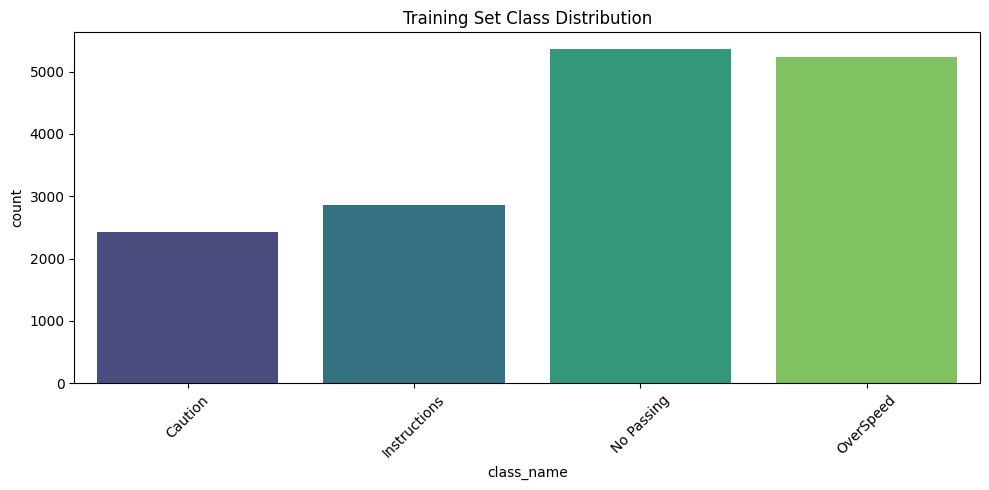

Saved: /content/traffic_sign_outputs/train_class_distribution.png


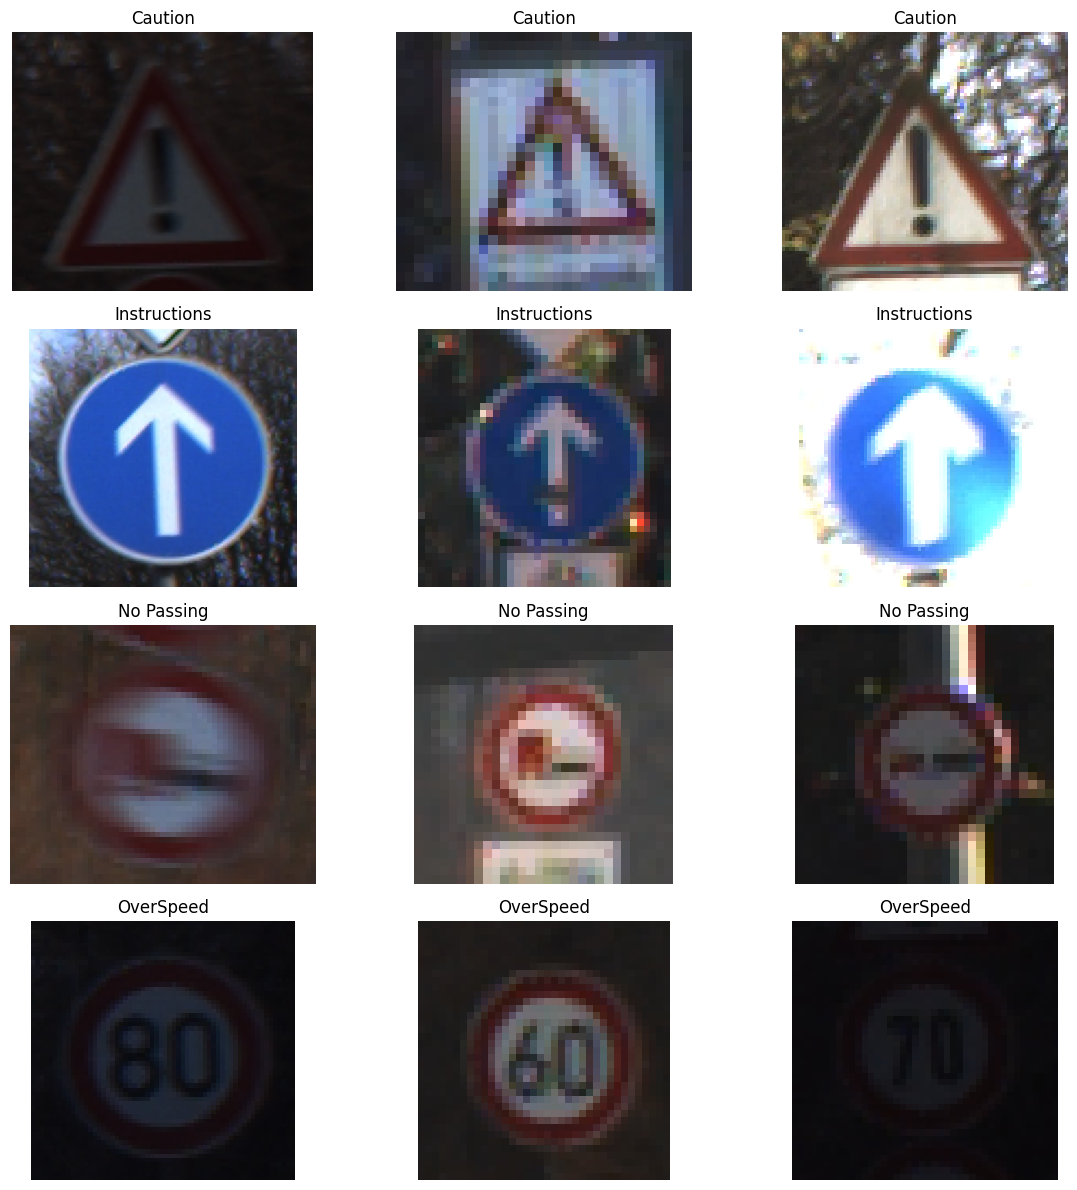

In [16]:
train_counts = train_df["label"].value_counts().sort_index()
distribution_df = train_counts.rename_axis("class_name").reset_index(name="train_count")

print("Class imbalance summary")
display(distribution_df)
plot_class_distribution(train_counts, "Training Set Class Distribution", "train_class_distribution.png")
show_sample_images_from_df(train_df)

## Train/Validation Split and Class Weights

In [18]:
train_split_df, val_split_df = train_test_split(
    train_df,
    test_size=0.2,
    stratify=train_df["label"],
    random_state=SEED,
)

train_split_df = train_split_df.reset_index(drop=True)
val_split_df = val_split_df.reset_index(drop=True)

class_weight_values = compute_class_weight(
    class_weight="balanced",
    classes=np.array(class_names),
    y=train_split_df["label"].values,
)
class_weights = {i: float(w) for i, w in enumerate(class_weight_values)}

print("Train split:", len(train_split_df))
print("Validation split:", len(val_split_df))
print("Class weights:")
for class_name, weight in zip(class_names, class_weight_values):
    print(class_name, "->", round(float(weight), 4))

Train split: 12706
Validation split: 3177
Class weights:
Caution -> 1.6391
Instructions -> 1.3895
No Passing -> 0.7406
OverSpeed -> 0.7576


## Targeted Augmentation for Imbalanced Classes

Classes below `AUGMENTATION_THRESHOLD` will have synthetic images generated until they reach the target count. Augmented images are saved to a temporary folder and added to the training dataframe.

Median class count : 3239
Augmentation target: 3239 (per minority class)
Threshold          : 2429 (classes below this get augmented)

Minority classes to augment: ['Instructions', 'Caution']

  Instructions: 2286 → target 3239  (generating 953 images)
  Caution: 1938 → target 3239  (generating 1301 images)

Augmentation complete.
Training set size after augmentation: 14960


/tmp/ipykernel_8244/3686833438.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="class_name", y="count", palette="viridis")


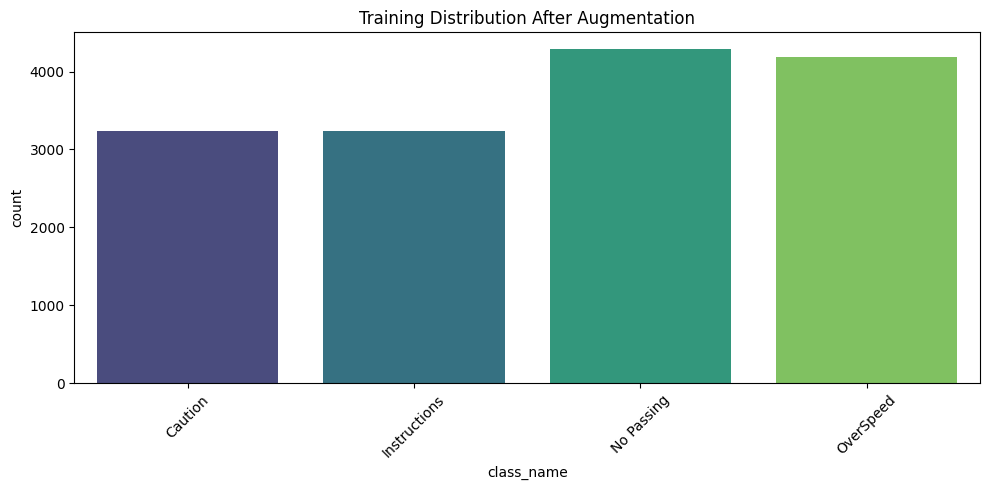

Saved: /content/traffic_sign_outputs/aug_class_distribution.png


In [18]:
# ── Targeted augmentation config ─────────────────────────────────────────────
AUGMENTATION_THRESHOLD = 0.75   # classes below 75% of median count get augmented
TARGET_MULTIPLIER     = 1.0     # augment up to the median count (1× median)
AUG_DIR = os.path.join(OUTPUT_DIR, "augmented_images")
os.makedirs(AUG_DIR, exist_ok=True)

# Aggressive augmentation generator for minority classes
minority_augmenter = ImageDataGenerator(
    rescale=1.0 / 255.0,
    rotation_range=25,
    width_shift_range=0.15,
    height_shift_range=0.15,
    zoom_range=0.20,
    shear_range=0.15,
    brightness_range=(0.70, 1.30),
    channel_shift_range=20.0,
    horizontal_flip=False,   # traffic signs are NOT horizontally symmetric
    fill_mode="nearest",
)

counts = train_split_df["label"].value_counts()
median_count = int(counts.median())
target_count  = int(median_count * TARGET_MULTIPLIER)
threshold     = int(median_count * AUGMENTATION_THRESHOLD)

print(f"Median class count : {median_count}")
print(f"Augmentation target: {target_count} (per minority class)")
print(f"Threshold          : {threshold} (classes below this get augmented)\n")

minority_classes = counts[counts < threshold].index.tolist()
print(f"Minority classes to augment: {minority_classes}\n")

new_records = []

for cls in minority_classes:
    cls_df = train_split_df[train_split_df["label"] == cls].copy()
    current_count = len(cls_df)
    needed = target_count - current_count
    if needed <= 0:
        continue

    print(f"  {cls}: {current_count} → target {target_count}  (generating {needed} images)")

    cls_aug_dir = os.path.join(AUG_DIR, cls)
    os.makedirs(cls_aug_dir, exist_ok=True)

    generated = 0
    while generated < needed:
        # pick a random source image from this class
        src_row = cls_df.sample(1, random_state=SEED + generated).iloc[0]
        img = Image.open(src_row["filepath"]).convert("RGB").resize(IMAGE_SIZE)
        img_array = np.array(img, dtype=np.float32)[np.newaxis, ...]  # (1, H, W, 3)

        for batch in minority_augmenter.flow(
            img_array,
            batch_size=1,
            save_to_dir=cls_aug_dir,
            save_prefix=f"{cls}_aug",
            save_format="png",
        ):
            generated += 1
            fname = sorted(os.listdir(cls_aug_dir))[-1]  # last saved file
            fpath = os.path.join(cls_aug_dir, fname)
            new_records.append({"filepath": fpath, "label": cls, "filename": fname})
            break  # one image per loop iteration

        if generated >= needed:
            break

print("\nAugmentation complete.")

if new_records:
    aug_df = pd.DataFrame(new_records)
    train_split_df = pd.concat([train_split_df, aug_df], ignore_index=True).sample(
        frac=1, random_state=SEED
    ).reset_index(drop=True)
    print(f"Training set size after augmentation: {len(train_split_df)}")

# Show updated distribution
aug_counts = train_split_df["label"].value_counts().sort_index()
plot_class_distribution(aug_counts, "Training Distribution After Augmentation", "aug_class_distribution.png")


### Visualisation of Augmented Images
Sample augmented images generated for minority classes (Section 2.5.1).

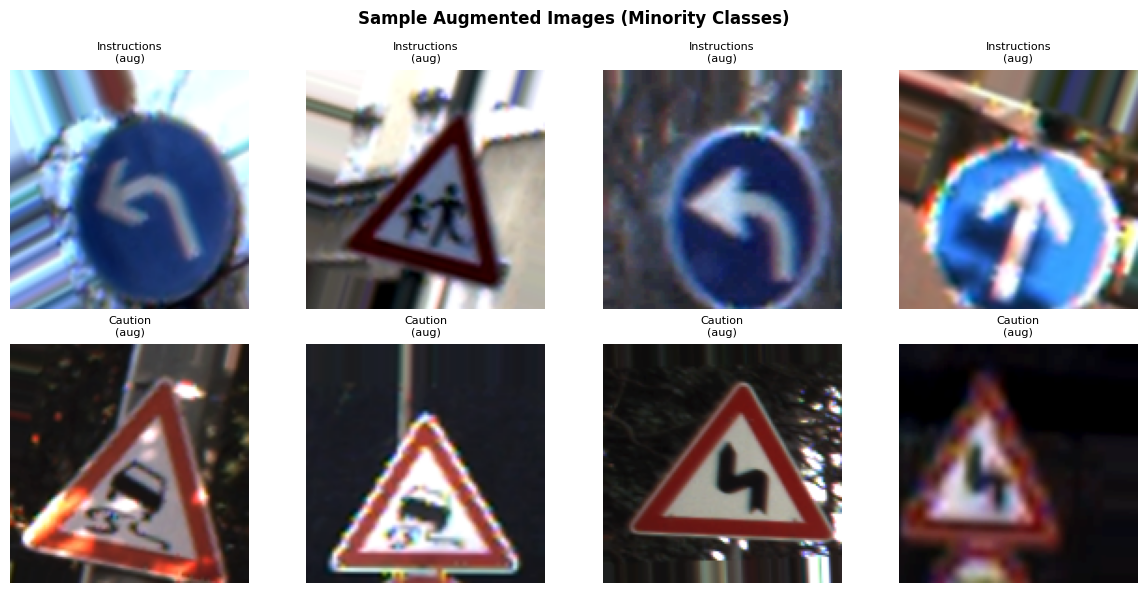

Saved: /content/traffic_sign_outputs/augmented_samples.png


In [19]:
def show_augmented_samples(aug_dir, n=4):
    class_dirs = [d for d in os.listdir(aug_dir)
                  if os.path.isdir(os.path.join(aug_dir, d))][:4]
    if not class_dirs:
        print("No augmented images found.")
        return
    fig, axes = plt.subplots(len(class_dirs), n,
                             figsize=(3 * n, 3 * len(class_dirs)))
    if len(class_dirs) == 1:
        axes = [axes]
    for row_idx, cls in enumerate(class_dirs):
        cls_path = os.path.join(aug_dir, cls)
        files = sorted(os.listdir(cls_path))[:n]
        for col_idx, fname in enumerate(files):
            img = Image.open(os.path.join(cls_path, fname)).convert("RGB")
            axes[row_idx][col_idx].imshow(img)
            axes[row_idx][col_idx].set_title(f"{cls}\n(aug)", fontsize=8)
            axes[row_idx][col_idx].axis("off")
        for col_idx in range(len(files), n):
            axes[row_idx][col_idx].axis("off")
    plt.suptitle("Sample Augmented Images (Minority Classes)",
                 fontsize=12, fontweight="bold")
    plt.tight_layout()
    save_path = os.path.join(OUTPUT_DIR, "augmented_samples.png")
    plt.savefig(save_path, dpi=150)
    plt.show()
    print("Saved:", save_path)

if os.path.isdir(AUG_DIR) and any(os.scandir(AUG_DIR)):
    show_augmented_samples(AUG_DIR)
else:
    print("All classes are balanced -- augmentation was skipped.")


## Generators

In [20]:
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255.0,
    rotation_range=15,
    width_shift_range=0.10,
    height_shift_range=0.10,
    zoom_range=0.10,
    shear_range=0.10,
    brightness_range=(0.8, 1.2),
    horizontal_flip=False,
    fill_mode="nearest",
)
eval_datagen = ImageDataGenerator(rescale=1.0 / 255.0)

train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_split_df,
    x_col="filepath",
    y_col="label",
    target_size=IMAGE_SIZE,
    class_mode="categorical",
    classes=class_names,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED,
)
val_generator = eval_datagen.flow_from_dataframe(
    dataframe=val_split_df,
    x_col="filepath",
    y_col="label",
    target_size=IMAGE_SIZE,
    class_mode="categorical",
    classes=class_names,
    batch_size=BATCH_SIZE,
    shuffle=False,
)
test_generator = eval_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col="filepath",
    y_col=None,
    target_size=IMAGE_SIZE,
    class_mode=None,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

print("Train samples:", train_generator.samples)
print("Validation samples:", val_generator.samples)
print("Flat test samples:", test_generator.samples)

Found 14960 validated image filenames belonging to 4 classes.
Found 3177 validated image filenames belonging to 4 classes.
Found 4 validated image filenames.
Train samples: 14960
Validation samples: 3177
Flat test samples: 4


In [20]:
def build_baseline_model(input_shape, num_classes):
    # FIX: Added Dropout to prevent overfitting / inflated accuracy
    return models.Sequential(
        [
            layers.Input(shape=input_shape),
            layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
            layers.MaxPooling2D((2, 2)),
            layers.Dropout(0.25),
            layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
            layers.MaxPooling2D((2, 2)),
            layers.Dropout(0.25),
            layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
            layers.MaxPooling2D((2, 2)),
            layers.Dropout(0.30),
            layers.Flatten(),
            layers.Dense(256, activation="relu"),
            layers.Dropout(0.50),
            layers.Dense(128, activation="relu"),
            layers.Dropout(0.30),
            layers.Dense(64, activation="relu"),
            layers.Dense(num_classes, activation="softmax"),
        ]
    )


def build_deeper_model(input_shape, num_classes, optimizer="adam"):
    model = models.Sequential(
        [
            layers.Input(shape=input_shape),
            layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
            layers.BatchNormalization(),
            layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
            layers.MaxPooling2D((2, 2)),
            layers.Dropout(0.25),
            layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
            layers.BatchNormalization(),
            layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
            layers.MaxPooling2D((2, 2)),
            layers.Dropout(0.25),
            layers.Conv2D(128, (3, 3), padding="same", activation="relu"),
            layers.BatchNormalization(),
            layers.Conv2D(128, (3, 3), padding="same", activation="relu"),
            layers.MaxPooling2D((2, 2)),
            layers.Dropout(0.30),
            layers.Flatten(),
            layers.Dense(512, activation="relu"),
            layers.BatchNormalization(),
            layers.Dropout(0.50),
            layers.Dense(256, activation="relu"),
            layers.Dropout(0.40),
            layers.Dense(128, activation="relu"),
            layers.Dense(num_classes, activation="softmax"),
        ]
    )

    opt = keras.optimizers.Adam(learning_rate=1e-3)
    if optimizer == "sgd":
        opt = keras.optimizers.SGD(learning_rate=1e-2, momentum=0.9)

    model.compile(optimizer=opt, loss="categorical_crossentropy", metrics=["accuracy"])
    return model


def build_transfer_model(num_classes):
    base_model = MobileNetV2(
        input_shape=(224, 224, 3),
        include_top=False,
        weights="imagenet",
    )
    base_model.trainable = False

    inputs = keras.Input(shape=(224, 224, 3))
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(256, activation="relu")(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = keras.Model(inputs, outputs)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model, base_model


## Baseline CNN

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     8,388,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,523,524 (32.51 MB)

 Trainable params: 8,523,524 (32.51 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
468/468 ━━━━━━━━━━━━━━━━━━━━ 162s 322ms/step - accuracy: 0.7646 - loss: 0.5607 - val_accuracy: 0.9367 - val_loss: 0.1725 - learning_rate: 0.0010
Epoch 2/20
468/468 ━━━━━━━━━━━━━━━━━━━━ 157s 335ms/step - accuracy: 0.9287 - loss: 0.2191 - val_accuracy: 0.9808 - val_loss: 0.0736 - learning_rate: 0.0010
Epoch 3/20
468/468 ━━━━━━━━━━━━━━━━━━━━ 143s 304ms/step - accuracy: 0.9496 - loss: 0.1531 - val_accuracy: 0.9868 - val_loss: 0.0369 - learning_rate: 0.0010
Epoch 4/20
468/468 ━━━━━━━━━━━━━━━━━━━━ 140s 298ms/step - accuracy: 0.9678 - loss: 0.1063 - val_accuracy: 0.9928 - val_loss: 0.0245 - learning_rate: 0.0010
Epoch 5/20
468/468 ━━━━━━━━━━━━━━━━━━━━ 139s 296ms/step - accuracy: 0.9749 - loss: 0.0759 - val_accuracy: 0.9975 - val_loss: 0.0096 - learning_rate: 0.0010
Epoch 6/20
468/468 ━━━━━━━━━━━━━━━━━━━━ 140s 299ms/step - accuracy: 0.9771 - loss: 0.0724 - val_accuracy: 0.9969 - val_loss: 0.0098 - learning_rate: 0.0010
Epoch 7/20
468/468 ━━━━━━━━━━━━━━━━━━━━ 0s 273ms/step - accuracy

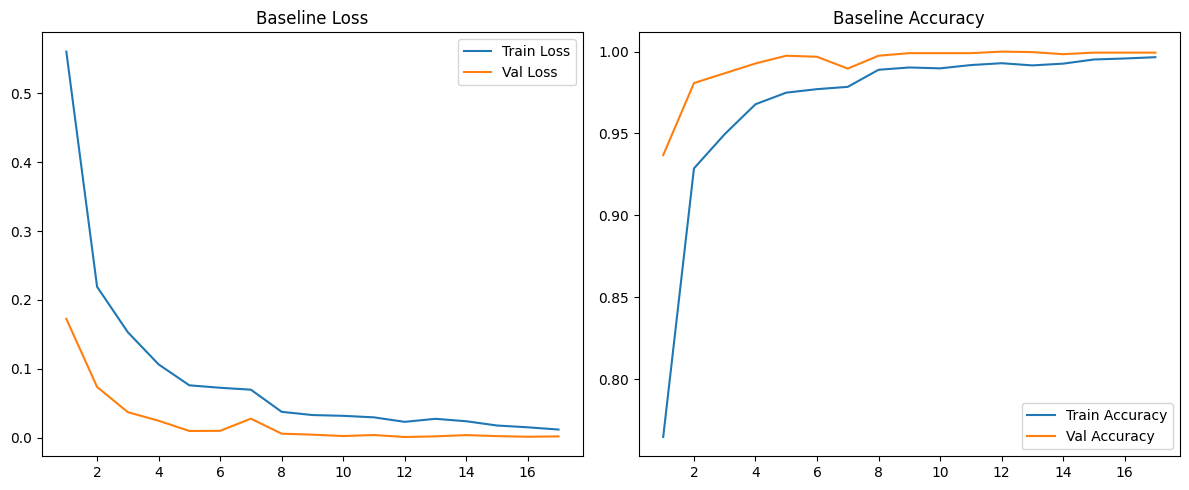

Saved: /content/traffic_sign_outputs/baseline_history.png
100/100 ━━━━━━━━━━━━━━━━━━━━ 11s 109ms/step - accuracy: 1.0000 - loss: 8.4889e-04
100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 115ms/step

Baseline CNN VALIDATION METRICS
Loss: 0.0008
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1: 1.0

Classification Report
              precision    recall  f1-score   support

     Caution       1.00      1.00      1.00       484
Instructions       1.00      1.00      1.00       571
  No Passing       1.00      1.00      1.00      1073
   OverSpeed       1.00      1.00      1.00      1049

    accuracy                           1.00      3177
   macro avg       1.00      1.00      1.00      3177
weighted avg       1.00      1.00      1.00      3177



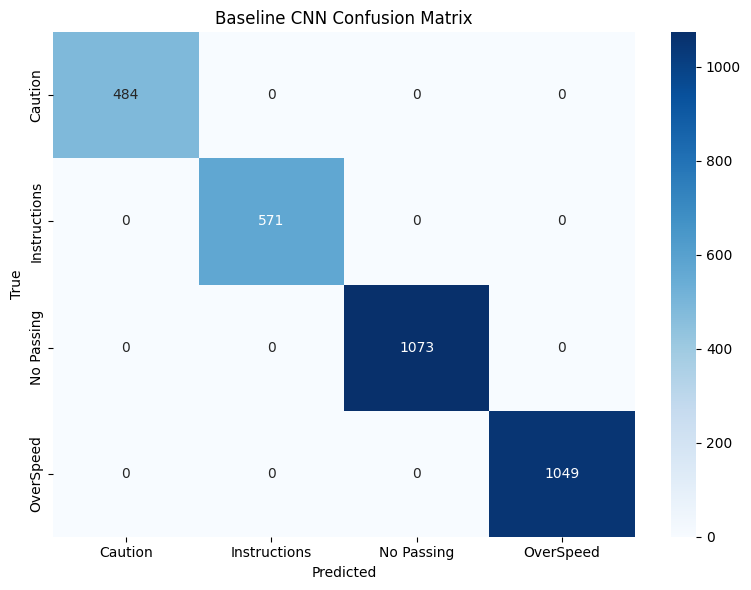

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 887ms/step

Baseline CNN FLAT TEST PREDICTIONS


,filename,predicted_class,confidence
0,00003_00000_00001.png,OverSpeed,0.999999
1,00009_00001_00027.png,No Passing,1.000000
2,00018_00000_00001.png,Caution,0.989360
3,00028_00000_00007.png,Instructions,0.999874


Saved: /content/traffic_sign_outputs/baseline_cnn_flat_test_predictions.csv


In [22]:
baseline_model = build_baseline_model(INPUT_SHAPE, len(class_names))
baseline_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)
baseline_model.summary()

start_time = time.time()
baseline_history = baseline_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=BASELINE_EPOCHS,
    callbacks=get_callbacks("baseline"),
    class_weight=class_weights,
    verbose=1,
)
baseline_time = time.time() - start_time

plot_training_history(baseline_history, "Baseline", "baseline")
baseline_metrics = evaluate_on_validation(baseline_model, val_generator, class_names, "Baseline CNN")
baseline_metrics["training_time_seconds"] = baseline_time
baseline_test_preds = predict_flat_test(
    baseline_model,
    test_generator,
    test_df["filename"].tolist(),
    class_names,
    "Baseline CNN",
)

## Sample Inference on Validation Images
Visualise per-image predictions with confidence scores (Section 2.5.2).

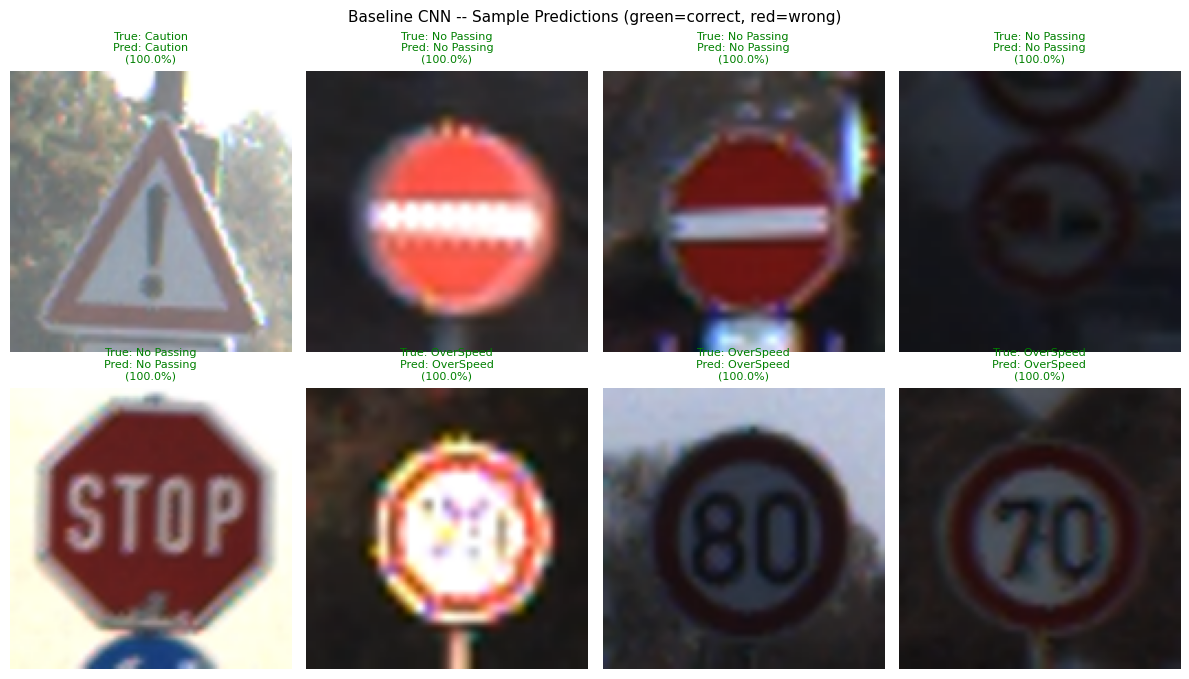

Saved: /content/traffic_sign_outputs/baseline_cnn_sample_preds.png


In [24]:
def plot_sample_predictions(model, val_df, class_names, model_name, n=8):
    sample = val_df.sample(n, random_state=SEED).reset_index(drop=True)
    fig, axes = plt.subplots(2, n // 2, figsize=(3 * (n // 2), 7))
    axes = axes.flatten()
    for idx, row in sample.iterrows():
        img_pil = Image.open(row["filepath"]).convert("RGB").resize(IMAGE_SIZE)
        img_arr = np.array(img_pil, dtype=np.float32) / 255.0
        pred = model.predict(img_arr[np.newaxis, ...], verbose=0)
        pred_class = class_names[np.argmax(pred)]
        confidence = np.max(pred)
        true_class = row["label"]
        color = "green" if pred_class == true_class else "red"
        axes[idx].imshow(img_pil)
        axes[idx].set_title(
            f"True: {true_class}\nPred: {pred_class}\n({confidence:.1%})",
            fontsize=8, color=color)
        axes[idx].axis("off")
    plt.suptitle(f"{model_name} -- Sample Predictions (green=correct, red=wrong)",
                 fontsize=11)
    plt.tight_layout()
    save_path = os.path.join(OUTPUT_DIR,
        f"{model_name.lower().replace(chr(32), chr(95))}_sample_preds.png")
    plt.savefig(save_path, dpi=150)
    plt.show()
    print("Saved:", save_path)

plot_sample_predictions(baseline_model, val_split_df, class_names, "Baseline CNN")


## Deeper CNN with Adam

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │    16,777,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 4)              │           51

 Total params: 17,232,420 (65.74 MB)

 Trainable params: 17,230,948 (65.73 MB)

 Non-trainable params: 1,472 (5.75 KB)

Epoch 1/25
468/468 ━━━━━━━━━━━━━━━━━━━━ 179s 347ms/step - accuracy: 0.8018 - loss: 0.4964 - val_accuracy: 0.6377 - val_loss: 0.8344 - learning_rate: 0.0010
Epoch 2/25
468/468 ━━━━━━━━━━━━━━━━━━━━ 159s 338ms/step - accuracy: 0.9505 - loss: 0.1491 - val_accuracy: 0.9770 - val_loss: 0.0709 - learning_rate: 0.0010
Epoch 3/25
468/468 ━━━━━━━━━━━━━━━━━━━━ 149s 317ms/step - accuracy: 0.9699 - loss: 0.0882 - val_accuracy: 0.9896 - val_loss: 0.0320 - learning_rate: 0.0010
Epoch 4/25
468/468 ━━━━━━━━━━━━━━━━━━━━ 148s 317ms/step - accuracy: 0.9741 - loss: 0.0761 - val_accuracy: 0.9972 - val_loss: 0.0075 - learning_rate: 0.0010
Epoch 5/25
468/468 ━━━━━━━━━━━━━━━━━━━━ 149s 316ms/step - accuracy: 0.9683 - loss: 0.0924 - val_accuracy: 0.9959 - val_loss: 0.0125 - learning_rate: 0.0010
Epoch 6/25
468/468 ━━━━━━━━━━━━━━━━━━━━ 0s 289ms/step - accuracy: 0.9852 - loss: 0.0500
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
468/468 ━━━━━━━━━━━━━━━━━━━━ 147s 313ms/step - accuracy:

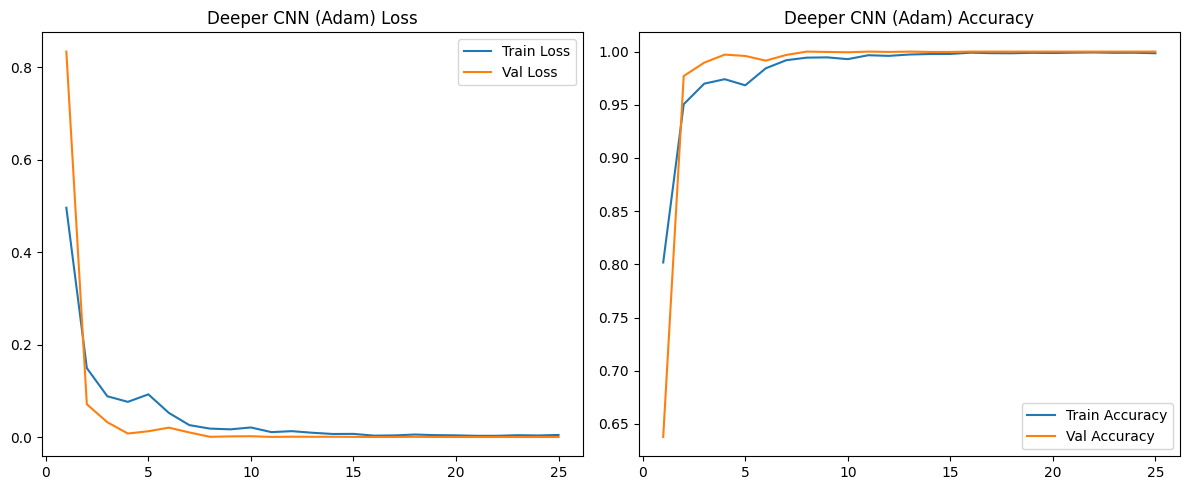

Saved: /content/traffic_sign_outputs/deeper_adam_history.png
100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 116ms/step - accuracy: 1.0000 - loss: 1.5931e-05
100/100 ━━━━━━━━━━━━━━━━━━━━ 13s 121ms/step

Deeper CNN (Adam) VALIDATION METRICS
Loss: 0.0
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1: 1.0

Classification Report
              precision    recall  f1-score   support

     Caution       1.00      1.00      1.00       484
Instructions       1.00      1.00      1.00       571
  No Passing       1.00      1.00      1.00      1073
   OverSpeed       1.00      1.00      1.00      1049

    accuracy                           1.00      3177
   macro avg       1.00      1.00      1.00      3177
weighted avg       1.00      1.00      1.00      3177



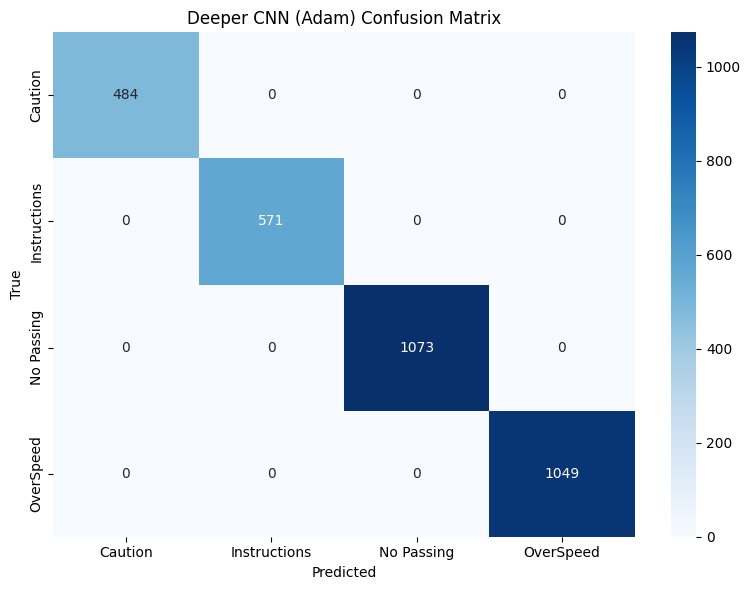

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step

Deeper CNN Adam FLAT TEST PREDICTIONS


,filename,predicted_class,confidence
0,00003_00000_00001.png,OverSpeed,1.000000
1,00009_00001_00027.png,No Passing,1.000000
2,00018_00000_00001.png,Caution,0.999995
3,00028_00000_00007.png,Instructions,1.000000


Saved: /content/traffic_sign_outputs/deeper_cnn_adam_flat_test_predictions.csv


In [25]:
deeper_model = build_deeper_model(INPUT_SHAPE, len(class_names), optimizer="adam")
deeper_model.summary()

start_time = time.time()
deeper_history = deeper_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=DEEP_EPOCHS,
    callbacks=get_callbacks("deeper_adam"),
    class_weight=class_weights,
    verbose=1,
)
deeper_time = time.time() - start_time

plot_training_history(deeper_history, "Deeper CNN (Adam)", "deeper_adam")
deeper_metrics = evaluate_on_validation(deeper_model, val_generator, class_names, "Deeper CNN (Adam)")
deeper_metrics["training_time_seconds"] = deeper_time
deeper_test_preds = predict_flat_test(
    deeper_model,
    test_generator,
    test_df["filename"].tolist(),
    class_names,
    "Deeper CNN Adam",
)

## 2.5.3 Observations: Deeper Model vs Baseline

**Architecture changes:** 6 Conv layers (3 paired blocks) vs 3 in baseline. BatchNormalization added after each block. Dense widths increased to 512→256→128.

**Expected improvements:**
- Greater depth extracts richer, more abstract features (edges → textures → sign shapes).
- BatchNormalization stabilises gradients and accelerates convergence.
- Dropout (0.25–0.50) prevents increased capacity from causing overfitting.

**Trade-offs:**
- Training time increases roughly 2–3x due to the larger parameter count.
- On small datasets, diminishing returns may limit the improvement over the baseline.
- The final comparison table quantifies accuracy, F1, and training time differences.

## Deeper CNN with SGD
Same architecture, different optimiser. Required for **Section 2.5.4 Optimizer Analysis**.

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 512)            │    16,777,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 4)              │           51

 Total params: 17,232,420 (65.74 MB)

 Trainable params: 17,230,948 (65.73 MB)

 Non-trainable params: 1,472 (5.75 KB)

Epoch 1/25
468/468 ━━━━━━━━━━━━━━━━━━━━ 172s 350ms/step - accuracy: 0.7302 - loss: 0.6550 - val_accuracy: 0.7391 - val_loss: 0.6401 - learning_rate: 0.0100
Epoch 2/25
468/468 ━━━━━━━━━━━━━━━━━━━━ 148s 316ms/step - accuracy: 0.9003 - loss: 0.2899 - val_accuracy: 0.9295 - val_loss: 0.2008 - learning_rate: 0.0100
Epoch 3/25
468/468 ━━━━━━━━━━━━━━━━━━━━ 156s 332ms/step - accuracy: 0.9216 - loss: 0.2284 - val_accuracy: 0.9600 - val_loss: 0.1296 - learning_rate: 0.0100
Epoch 4/25
468/468 ━━━━━━━━━━━━━━━━━━━━ 145s 309ms/step - accuracy: 0.9453 - loss: 0.1627 - val_accuracy: 0.9698 - val_loss: 0.0891 - learning_rate: 0.0100
Epoch 5/25
468/468 ━━━━━━━━━━━━━━━━━━━━ 147s 314ms/step - accuracy: 0.9601 - loss: 0.1214 - val_accuracy: 0.9921 - val_loss: 0.0353 - learning_rate: 0.0100
Epoch 6/25
468/468 ━━━━━━━━━━━━━━━━━━━━ 147s 313ms/step - accuracy: 0.9636 - loss: 0.1079 - val_accuracy: 0.9726 - val_loss: 0.0754 - learning_rate: 0.0100
Epoch 7/25
468/468 ━━━━━━━━━━━━━━━━━━━━ 0s 289ms/step - accuracy

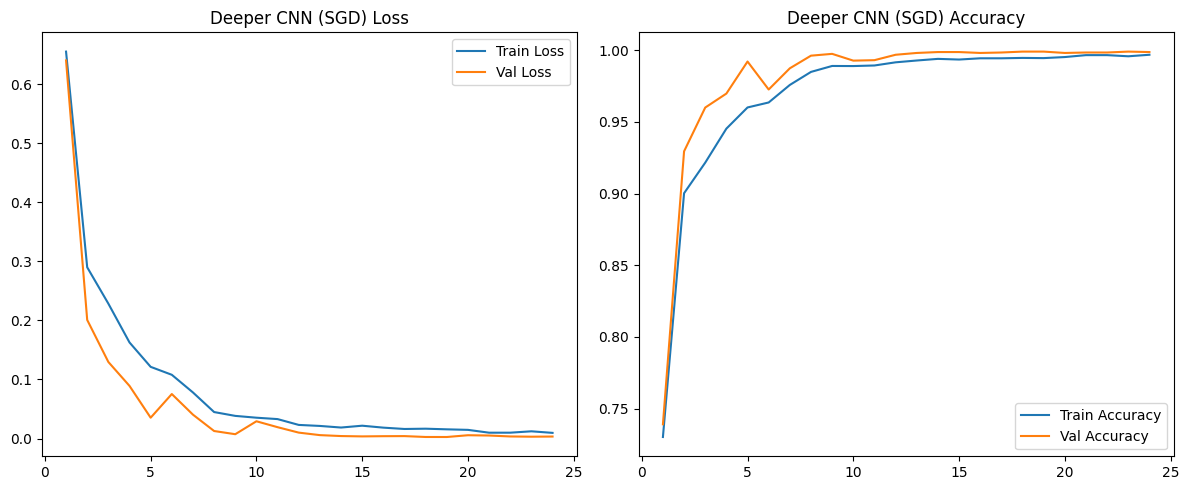

Saved: /content/traffic_sign_outputs/deeper_sgd_history.png
100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 117ms/step - accuracy: 0.9991 - loss: 0.0026
100/100 ━━━━━━━━━━━━━━━━━━━━ 13s 120ms/step

Deeper CNN (SGD) VALIDATION METRICS
Loss: 0.0026
Accuracy: 0.9991
Precision: 0.9991
Recall: 0.9991
F1: 0.9991

Classification Report
              precision    recall  f1-score   support

     Caution       1.00      1.00      1.00       484
Instructions       1.00      0.99      1.00       571
  No Passing       1.00      1.00      1.00      1073
   OverSpeed       1.00      1.00      1.00      1049

    accuracy                           1.00      3177
   macro avg       1.00      1.00      1.00      3177
weighted avg       1.00      1.00      1.00      3177



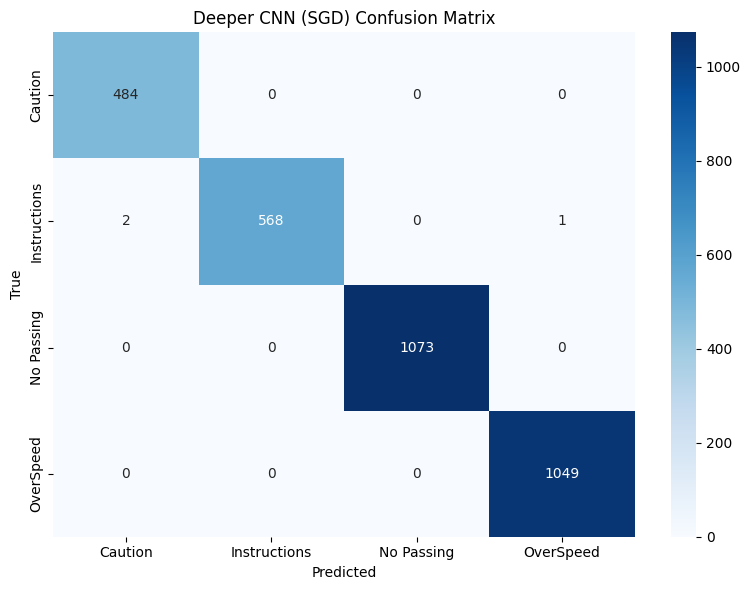

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step

Deeper CNN SGD FLAT TEST PREDICTIONS


,filename,predicted_class,confidence
0,00003_00000_00001.png,OverSpeed,0.999999
1,00009_00001_00027.png,No Passing,1.000000
2,00018_00000_00001.png,Caution,0.999895
3,00028_00000_00007.png,Instructions,0.999994


Saved: /content/traffic_sign_outputs/deeper_cnn_sgd_flat_test_predictions.csv


In [26]:
deeper_sgd_model = build_deeper_model(INPUT_SHAPE, len(class_names), optimizer="sgd")
deeper_sgd_model.summary()

start_time = time.time()
deeper_sgd_history = deeper_sgd_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=DEEP_EPOCHS,
    callbacks=get_callbacks("deeper_sgd"),
    class_weight=class_weights,
    verbose=1,
)
deeper_sgd_time = time.time() - start_time

plot_training_history(deeper_sgd_history, "Deeper CNN (SGD)", "deeper_sgd")
deeper_sgd_metrics = evaluate_on_validation(
    deeper_sgd_model, val_generator, class_names, "Deeper CNN (SGD)")
deeper_sgd_metrics["training_time_seconds"] = deeper_sgd_time
deeper_sgd_test_preds = predict_flat_test(
    deeper_sgd_model, test_generator,
    test_df["filename"].tolist(), class_names, "Deeper CNN SGD")


In [ ]:
def compare_histories(history_baseline, history_deeper):
    base = history_baseline.history
    deep = history_deeper.history

    epochs_base = range(1, len(base["accuracy"]) + 1)
    epochs_deep = range(1, len(deep["accuracy"]) + 1)

    # Accuracy
    plt.figure(figsize=(10, 6))
    plt.plot(epochs_base, base["accuracy"], label="Baseline Train Accuracy")
    plt.plot(epochs_base, base["val_accuracy"], label="Baseline Val Accuracy")
    plt.plot(epochs_deep, deep["accuracy"], label="Deeper Train Accuracy")
    plt.plot(epochs_deep, deep["val_accuracy"], label="Deeper Val Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Baseline vs Deeper Architecture - Accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()

    # Loss
    plt.figure(figsize=(10, 6))
    plt.plot(epochs_base, base["loss"], label="Baseline Train Loss")
    plt.plot(epochs_base, base["val_loss"], label="Baseline Val Loss")
    plt.plot(epochs_deep, deep["loss"], label="Deeper Train Loss")
    plt.plot(epochs_deep, deep["val_loss"], label="Deeper Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Baseline vs Deeper Architecture - Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

### Optimizer Comparison: Adam vs SGD
Side-by-side convergence curves (Section 2.5.4).

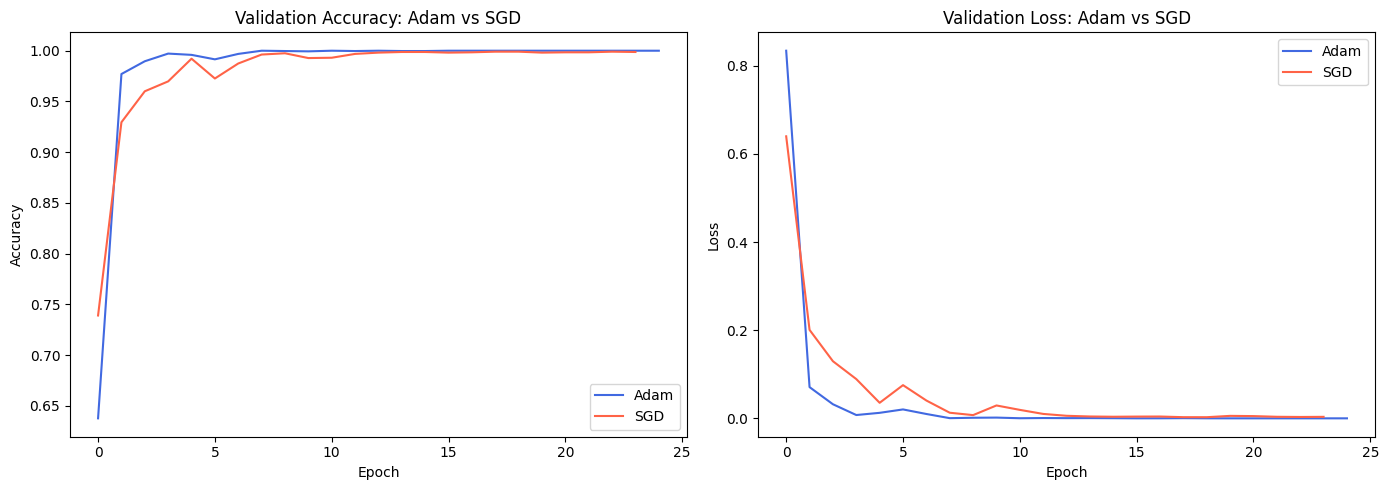

Saved: /content/traffic_sign_outputs/optimizer_comparison.png
Adam -- Accuracy: 1.0000  F1: 1.0000  Time: 3770s
SGD  -- Accuracy: 0.9991  F1: 0.9991  Time: 3589s


In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for hist, label, color in [
    (deeper_history.history,     "Adam", "royalblue"),
    (deeper_sgd_history.history, "SGD",  "tomato"),
]:
    axes[0].plot(hist["val_accuracy"], label=label, color=color)
    axes[1].plot(hist["val_loss"],     label=label, color=color)
axes[0].set_title("Validation Accuracy: Adam vs SGD")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Accuracy"); axes[0].legend()
axes[1].set_title("Validation Loss: Adam vs SGD")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Loss");     axes[1].legend()
plt.tight_layout()
opt_cmp_path = os.path.join(OUTPUT_DIR, "optimizer_comparison.png")
plt.savefig(opt_cmp_path, dpi=200); plt.show()
print("Saved:", opt_cmp_path)

print("Adam -- Accuracy: {:.4f}  F1: {:.4f}  Time: {:.0f}s".format(
    deeper_metrics["accuracy"], deeper_metrics["f1_score"],
    deeper_metrics["training_time_seconds"]))
print("SGD  -- Accuracy: {:.4f}  F1: {:.4f}  Time: {:.0f}s".format(
    deeper_sgd_metrics["accuracy"], deeper_sgd_metrics["f1_score"],
    deeper_sgd_metrics["training_time_seconds"]))


## Ablation Study -- Removing Dropout
We remove all Dropout layers from the deeper model to measure their contribution to regularisation (Section 2.5.4).

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_15 (Conv2D)              │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 512)            │    16,777,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,232,420 (65.74 MB)

 Trainable params: 17,230,948 (65.73 MB)

 Non-trainable params: 1,472 (5.75 KB)

Epoch 1/25
468/468 ━━━━━━━━━━━━━━━━━━━━ 165s 336ms/step - accuracy: 0.9120 - loss: 0.2495 - val_accuracy: 0.9673 - val_loss: 0.1104 - learning_rate: 0.0010
Epoch 2/25
468/468 ━━━━━━━━━━━━━━━━━━━━ 152s 325ms/step - accuracy: 0.9770 - loss: 0.0699 - val_accuracy: 0.9928 - val_loss: 0.0238 - learning_rate: 0.0010
Epoch 3/25
468/468 ━━━━━━━━━━━━━━━━━━━━ 156s 325ms/step - accuracy: 0.9864 - loss: 0.0429 - val_accuracy: 0.9515 - val_loss: 0.1461 - learning_rate: 0.0010
Epoch 4/25
468/468 ━━━━━━━━━━━━━━━━━━━━ 151s 323ms/step - accuracy: 0.9878 - loss: 0.0371 - val_accuracy: 0.9962 - val_loss: 0.0103 - learning_rate: 0.0010
Epoch 5/25
468/468 ━━━━━━━━━━━━━━━━━━━━ 150s 320ms/step - accuracy: 0.9888 - loss: 0.0365 - val_accuracy: 0.9934 - val_loss: 0.0265 - learning_rate: 0.0010
Epoch 6/25
468/468 ━━━━━━━━━━━━━━━━━━━━ 151s 322ms/step - accuracy: 0.9932 - loss: 0.0246 - val_accuracy: 0.9975 - val_loss: 0.0070 - learning_rate: 0.0010
Epoch 7/25
468/468 ━━━━━━━━━━━━━━━━━━━━ 151s 321ms/step - accura

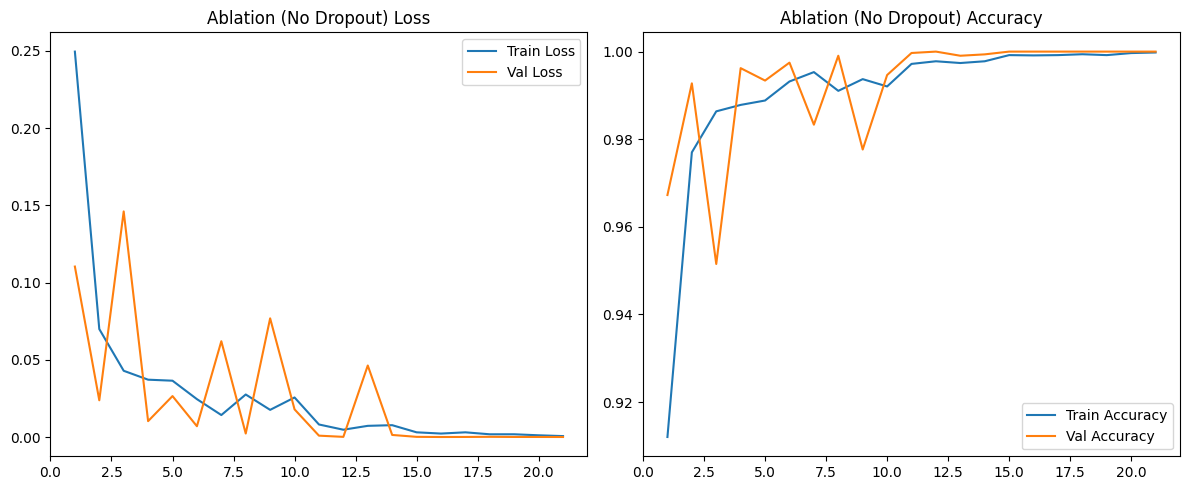

Saved: /content/traffic_sign_outputs/ablation_no_dropout_history.png
100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 116ms/step - accuracy: 1.0000 - loss: 3.6393e-05
100/100 ━━━━━━━━━━━━━━━━━━━━ 13s 122ms/step

Ablation (No Dropout) VALIDATION METRICS
Loss: 0.0
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1: 1.0

Classification Report
              precision    recall  f1-score   support

     Caution       1.00      1.00      1.00       484
Instructions       1.00      1.00      1.00       571
  No Passing       1.00      1.00      1.00      1073
   OverSpeed       1.00      1.00      1.00      1049

    accuracy                           1.00      3177
   macro avg       1.00      1.00      1.00      3177
weighted avg       1.00      1.00      1.00      3177



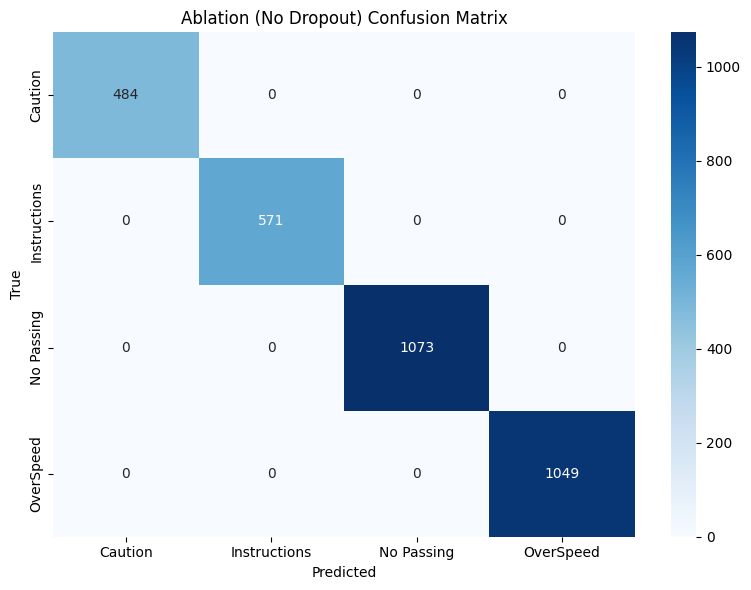


-- Ablation Summary --
Full Deeper (with Dropout) -- Accuracy: 1.0000  F1: 1.0000
No-Dropout Ablation        -- Accuracy: 1.0000  F1: 1.0000
Train-val accuracy gap  -- With Dropout: -0.0015  |  No Dropout: -0.0002
A larger gap without Dropout confirms Dropout reduces overfitting.


In [28]:
def build_no_dropout_model(input_shape, num_classes):
    """Deeper model with Dropout removed -- ablation study."""
    model = models.Sequential([
        layers.Input(shape=input_shape),
        layers.Conv2D(32,  (3, 3), padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.Conv2D(32,  (3, 3), padding="same", activation="relu"),
        layers.MaxPooling2D((2, 2)),
        # Dropout removed
        layers.Conv2D(64,  (3, 3), padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.Conv2D(64,  (3, 3), padding="same", activation="relu"),
        layers.MaxPooling2D((2, 2)),
        # Dropout removed
        layers.Conv2D(128, (3, 3), padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.Conv2D(128, (3, 3), padding="same", activation="relu"),
        layers.MaxPooling2D((2, 2)),
        # Dropout removed
        layers.Flatten(),
        layers.Dense(512, activation="relu"),
        layers.BatchNormalization(),
        # Dropout removed
        layers.Dense(256, activation="relu"),
        layers.Dense(128, activation="relu"),
        layers.Dense(num_classes, activation="softmax"),
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


ablation_model = build_no_dropout_model(INPUT_SHAPE, len(class_names))
ablation_model.summary()

start_time = time.time()
ablation_history = ablation_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=DEEP_EPOCHS,
    callbacks=get_callbacks("ablation_no_dropout"),
    class_weight=class_weights,
    verbose=1,
)
ablation_time = time.time() - start_time

plot_training_history(ablation_history, "Ablation (No Dropout)", "ablation_no_dropout")
ablation_metrics = evaluate_on_validation(
    ablation_model, val_generator, class_names, "Ablation (No Dropout)")
ablation_metrics["training_time_seconds"] = ablation_time

print("\n-- Ablation Summary --")
print("Full Deeper (with Dropout) -- Accuracy: {:.4f}  F1: {:.4f}".format(
    deeper_metrics["accuracy"], deeper_metrics["f1_score"]))
print("No-Dropout Ablation        -- Accuracy: {:.4f}  F1: {:.4f}".format(
    ablation_metrics["accuracy"], ablation_metrics["f1_score"]))

d_gap = deeper_history.history["accuracy"][-1] - deeper_history.history["val_accuracy"][-1]
a_gap = ablation_history.history["accuracy"][-1] - ablation_history.history["val_accuracy"][-1]
print(f"Train-val accuracy gap  -- With Dropout: {d_gap:.4f}  |  No Dropout: {a_gap:.4f}")
print("A larger gap without Dropout confirms Dropout reduces overfitting.")


## Transfer Learning

In [ ]:
tl_train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,
    width_shift_range=0.10,
    height_shift_range=0.10,
    zoom_range=0.10,
    brightness_range=(0.8, 1.2),
    fill_mode="nearest",
)
tl_eval_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

tl_train_generator = tl_train_datagen.flow_from_dataframe(
    dataframe=train_split_df,
    x_col="filepath",
    y_col="label",
    target_size=(224, 224),
    class_mode="categorical",
    classes=class_names,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED,
)
tl_val_generator = tl_eval_datagen.flow_from_dataframe(
    dataframe=val_split_df,
    x_col="filepath",
    y_col="label",
    target_size=(224, 224),
    class_mode="categorical",
    classes=class_names,
    batch_size=BATCH_SIZE,
    shuffle=False,
)
tl_test_generator = tl_eval_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col="filepath",
    y_col=None,
    target_size=(224, 224),
    class_mode=None,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

transfer_model, transfer_base = build_transfer_model(len(class_names))
transfer_model.summary()

start_time = time.time()
transfer_head_history = transfer_model.fit(
    tl_train_generator,
    validation_data=tl_val_generator,
    epochs=TRANSFER_HEAD_EPOCHS,
    callbacks=get_callbacks("transfer_head"),
    class_weight=class_weights,
    verbose=1,
)

transfer_base.trainable = True
for layer in transfer_base.layers[:-30]:
    layer.trainable = False

transfer_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

transfer_finetune_history = transfer_model.fit(
    tl_train_generator,
    validation_data=tl_val_generator,
    epochs=TRANSFER_FINE_TUNE_EPOCHS,
    callbacks=get_callbacks("transfer_finetune"),
    class_weight=class_weights,
    verbose=1,
)
transfer_time = time.time() - start_time

plot_training_history(transfer_head_history, "Transfer Head", "transfer_head")
plot_training_history(transfer_finetune_history, "Transfer Fine-tune", "transfer_finetune")
transfer_metrics = evaluate_on_validation(transfer_model, tl_val_generator, class_names, "Transfer Learning")
transfer_metrics["training_time_seconds"] = transfer_time
transfer_test_preds = predict_flat_test(
    transfer_model,
    tl_test_generator,
    test_df["filename"].tolist(),
    class_names,
    "Transfer Learning",
)

Found 12706 validated image filenames belonging to 4 classes.
Found 3177 validated image filenames belonging to 4 classes.
Found 4 validated image filenames.
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,586,948 (9.87 MB)

 Trainable params: 328,964 (1.25 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/8
398/398 ━━━━━━━━━━━━━━━━━━━━ 1035s 3s/step - accuracy: 0.8957 - loss: 0.2842 - val_accuracy: 0.9424 - val_loss: 0.1513 - learning_rate: 0.0010
Epoch 2/8
398/398 ━━━━━━━━━━━━━━━━━━━━ 961s 2s/step - accuracy: 0.9420 - loss: 0.1611 - val_accuracy: 0.9393 - val_loss: 0.1529 - learning_rate: 0.0010
Epoch 3/8
398/398 ━━━━━━━━━━━━━━━━━━━━ 951s 2s/step - accuracy: 0.9533 - loss: 0.1244 - val_accuracy: 0.9632 - val_loss: 0.1019 - learning_rate: 0.0010
Epoch 4/8
398/398 ━━━━━━━━━━━━━━━━━━━━ 975s 2s/step - accuracy: 0.9571 - loss: 0.1097 - val_accuracy: 0.9613 - val_loss: 0.0923 - learning_rate: 0.0010
Epoch 5/8
249/398 ━━━━━━━━━━━━━━━━━━━━ 5:00 2s/step - accuracy: 0.9631 - loss: 0.0923

## Comparison and Summary

In [ ]:
plot_sample_predictions(deeper_model,   val_split_df, class_names, "Deeper CNN (Adam)")
plot_sample_predictions(transfer_model, val_split_df, class_names, "Transfer Learning")


In [ ]:
comparison_df = pd.DataFrame([
    {"Model": "Baseline CNN",
     "Loss": baseline_metrics["loss"], "Accuracy": baseline_metrics["accuracy"],
     "Precision": baseline_metrics["precision"], "Recall": baseline_metrics["recall"],
     "F1 Score": baseline_metrics["f1_score"],
     "Training Time (s)": baseline_metrics["training_time_seconds"]},
    {"Model": "Deeper CNN (Adam)",
     "Loss": deeper_metrics["loss"], "Accuracy": deeper_metrics["accuracy"],
     "Precision": deeper_metrics["precision"], "Recall": deeper_metrics["recall"],
     "F1 Score": deeper_metrics["f1_score"],
     "Training Time (s)": deeper_metrics["training_time_seconds"]},
    {"Model": "Deeper CNN (SGD)",
     "Loss": deeper_sgd_metrics["loss"], "Accuracy": deeper_sgd_metrics["accuracy"],
     "Precision": deeper_sgd_metrics["precision"], "Recall": deeper_sgd_metrics["recall"],
     "F1 Score": deeper_sgd_metrics["f1_score"],
     "Training Time (s)": deeper_sgd_metrics["training_time_seconds"]},
    {"Model": "Ablation (No Dropout)",
     "Loss": ablation_metrics["loss"], "Accuracy": ablation_metrics["accuracy"],
     "Precision": ablation_metrics["precision"], "Recall": ablation_metrics["recall"],
     "F1 Score": ablation_metrics["f1_score"],
     "Training Time (s)": ablation_metrics["training_time_seconds"]},
    {"Model": "Transfer Learning (MobileNetV2)",
     "Loss": transfer_metrics["loss"], "Accuracy": transfer_metrics["accuracy"],
     "Precision": transfer_metrics["precision"], "Recall": transfer_metrics["recall"],
     "F1 Score": transfer_metrics["f1_score"],
     "Training Time (s)": transfer_metrics["training_time_seconds"]},
])

display(comparison_df.round(4))
comparison_path = os.path.join(OUTPUT_DIR, "model_comparison.csv")
comparison_df.to_csv(comparison_path, index=False)
print("Saved:", comparison_path)

# Bar chart comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = ["steelblue", "seagreen", "tomato", "goldenrod", "mediumpurple"]
for ax, metric in zip(axes, ["Accuracy", "F1 Score", "Training Time (s)"]):
    bars = ax.bar(comparison_df["Model"], comparison_df[metric], color=colors)
    ax.set_title(metric)
    ax.set_xticklabels(comparison_df["Model"], rotation=25, ha="right", fontsize=8)
    ax.bar_label(bars, fmt="%.3f", fontsize=7)
plt.suptitle("Model Comparison Summary", fontsize=13, fontweight="bold")
plt.tight_layout()
bar_path = os.path.join(OUTPUT_DIR, "model_comparison_bar.png")
plt.savefig(bar_path, dpi=200); plt.show(); print("Saved:", bar_path)

summary = {
    "dataset_root": DATASET_ROOT, "num_classes": len(class_names),
    "train_images": len(train_df), "validation_images": len(val_split_df),
    "flat_test_images": len(test_df),
    "invalid_train_images_skipped": len(invalid_train_files),
    "invalid_test_images_skipped":  len(invalid_test_files),
    "class_weights": class_weights,
    "models": {
        "baseline":            baseline_metrics,
        "deeper_adam":         deeper_metrics,
        "deeper_sgd":          deeper_sgd_metrics,
        "ablation_no_dropout": ablation_metrics,
        "transfer_learning":   transfer_metrics,
    },
}
summary_path = os.path.join(OUTPUT_DIR, "assignment_summary.json")
with open(summary_path, "w", encoding="utf-8") as file:
    json.dump(summary, file, indent=2)
print("Saved:", summary_path)
